In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

In [3]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [24]:
def _image_label_from_key(k):
    return Path(str(k).replace("\\", "/")).stem


def _safe_session_order(metadata):
    if metadata is None:
        return np.nan

    if "session_#" in metadata:
        return metadata["session_#"]

    for key in ["session_num", "session_number", "session_order"]:
        if key in metadata:
            return metadata[key]

    return np.nan


def _collapse_trials_to_amplitude(arr, amplitude_func="mean"):
    """
    Collapse an array of shape (n_trials, n_time) to one scalar per trial.
    """
    if amplitude_func == "mean":
        return np.nanmean(arr, axis=1)
    elif amplitude_func == "max":
        return np.nanmax(arr, axis=1)
    elif amplitude_func == "sum":
        return np.nansum(arr, axis=1)
    elif amplitude_func == "top10":
        k = min(10, arr.shape[1])
        part = np.partition(arr, -k, axis=1)[:, -k:]
        return np.nanmean(part, axis=1)
    else:
        raise ValueError(f"Unknown amplitude_func: {amplitude_func}")


def _compute_scalar_image_variance_metrics_for_synapse(
    image_trials_by_label,
    sample_slice=slice(50, 100),
    amplitude_func="mean",
):
    """
    For one synapse:
      1) time-average each presentation response into one scalar
      2) compute total variance across all scalar presentation responses
      3) subtract image-identity means only within matching image identities
      4) compute image-explained fraction of variance

    Returns
    -------
    dict or None
        total_var
        mean_residual_var
        mean_fve
        image_residual_var
        image_fve_total
        image_fve_by_label
        n_trials_total
        n_images_present
        grand_mean
    """
    labels = []
    amplitude_blocks = []

    for label, arr in image_trials_by_label.items():
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 2 or arr.shape[0] == 0:
            continue

        arr = arr[:, sample_slice]
        if arr.size == 0:
            continue

        amp = _collapse_trials_to_amplitude(arr, amplitude_func=amplitude_func)
        amplitude_blocks.append(amp)
        labels.extend([label] * len(amp))

    if not amplitude_blocks:
        return None

    y = np.concatenate(amplitude_blocks, axis=0)
    labels = np.asarray(labels)

    valid = np.isfinite(y)
    y = y[valid]
    labels = labels[valid]

    if y.size < 2:
        return None

    total_var = np.var(y)
    if not np.isfinite(total_var) or total_var <= 0:
        return None

    # ------------------------------------------------------------
    # Global mean subtraction on scalar amplitudes
    # This does not change variance, so mean_fve = 0 by construction.
    # We keep it explicitly for clarity.
    # ------------------------------------------------------------
    grand_mean = np.mean(y)
    mean_residual = y - grand_mean
    mean_residual_var = np.var(mean_residual)
    mean_fve = 1.0 - (mean_residual_var / total_var)

    # ------------------------------------------------------------
    # Image-identity subtraction:
    # subtract only the mean of the corresponding image identity
    # from trials belonging to that image
    # ------------------------------------------------------------
    image_residual = np.empty_like(y)
    image_fve_by_label = {}

    for lab in np.unique(labels):
        mask = labels == lab
        y_lab = y[mask]

        if y_lab.size < 1:
            image_fve_by_label[lab] = np.nan
            continue

        mu_lab = np.mean(y_lab)
        resid_lab = y_lab - mu_lab
        image_residual[mask] = resid_lab

        resid_var_lab = np.var(resid_lab)
        image_fve_by_label[lab] = 1.0 - (resid_var_lab / total_var)

    image_residual_var = np.var(image_residual)
    image_fve_total = 1.0 - (image_residual_var / total_var)

    return {
        "total_var": float(total_var),
        "mean_residual_var": float(mean_residual_var),
        "mean_fve": float(mean_fve),
        "image_residual_var": float(image_residual_var),
        "image_fve_total": float(image_fve_total),
        "image_fve_by_label": image_fve_by_label,
        "n_trials_total": int(y.size),
        "n_images_present": int(len(np.unique(labels))),
        "grand_mean": float(grand_mean),
    }

def _image_label_from_key(k):
    return Path(str(k).replace("\\", "/")).stem


def _compute_curve_image_metrics_for_synapse(
    image_trials_by_label,
    sample_slice=slice(50, 100),
    min_trials_per_image=2,
):
    """
    For one synapse, use full dFF response curves to quantify the
    image-dependent component.

    Parameters
    ----------
    image_trials_by_label : dict[label -> array]
        Each array should be shape (n_trials, n_time)
    sample_slice : slice
        Time window to analyze
    min_trials_per_image : int
        Minimum repeats required to include an image

    Returns
    -------
    dict or None
        total_var_curve
        residual_var_curve
        image_var_curve
        image_fve_curve
        image_rms_dff
        n_trials_total
        n_images_present
    """
    blocks = []
    labels = []

    for label, arr in image_trials_by_label.items():
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 2 or arr.shape[0] < min_trials_per_image:
            continue

        arr = arr[:, sample_slice]
        if arr.size == 0:
            continue

        # optional: subtract per-trial prestim baseline if your dFF traces are not already baseline-centered
        blocks.append(arr)
        labels.extend([label] * arr.shape[0])

    if not blocks:
        return None

    Y = np.concatenate(blocks, axis=0)   # (n_trials_total, n_time)
    labels = np.asarray(labels)

    # remove trials with all non-finite values
    keep = np.any(np.isfinite(Y), axis=1)
    Y = Y[keep]
    labels = labels[keep]

    if Y.shape[0] < 2:
        return None

    # grand mean curve
    mu = np.nanmean(Y, axis=0, keepdims=True)

    # total variance around grand mean curve
    total_var_curve = np.nanmean((Y - mu) ** 2)
    if not np.isfinite(total_var_curve) or total_var_curve <= 0:
        return None

    # residual after subtracting image-specific mean curves
    resid = np.full_like(Y, np.nan)

    for lab in np.unique(labels):
        mask = labels == lab
        Y_lab = Y[mask]
        if Y_lab.shape[0] < min_trials_per_image:
            continue

        mu_lab = np.nanmean(Y_lab, axis=0, keepdims=True)
        resid[mask] = Y_lab - mu_lab

    residual_var_curve = np.nanmean(resid ** 2)
    image_var_curve = total_var_curve - residual_var_curve
    image_var_curve = max(image_var_curve, 0.0)

    image_fve_curve = image_var_curve / total_var_curve
    image_rms_dff = np.sqrt(image_var_curve)

    return {
        "total_var_curve": float(total_var_curve),
        "residual_var_curve": float(residual_var_curve),
        "image_var_curve": float(image_var_curve),
        "image_fve_curve": float(image_fve_curve),
        "image_rms_dff": float(image_rms_dff),
        "n_trials_total": int(Y.shape[0]),
        "n_images_present": int(len(np.unique(labels))),
    }

def compute_curve_selectivity_across_sessions(
    single_trial_paths,
    assets,
    act_summary,
    sample_slice=slice(50, 100),
    allowed_depths=(25, 100, 200, 250),
):
    activated_lookup = (
        act_summary.loc[
            act_summary["stimulus_family"] == "image",
            ["session_id", "dmd", "synapse_id"]
        ]
        .drop_duplicates()
    )

    activated_sets = {
        (sid, dmd): set(df["synapse_id"].tolist())
        for (sid, dmd), df in activated_lookup.groupby(["session_id", "dmd"])
    }

    rows = []

    for i, path in enumerate(single_trial_paths):
        asset = assets[i]
        session_id = asset.session_id
        metadata = getattr(asset, "metadata", {}) or {}

        data = np.load(path, allow_pickle=True)["data"][0]

        depth_map = {
            "DMD1": metadata.get("dmd1_depth", np.nan),
            "DMD2": metadata.get("dmd2_depth", np.nan),
        }

        session_type = metadata.get("session_type", np.nan)
        session_order = metadata.get("session_#", np.nan)

        for dmd_name in ["DMD1", "DMD2"]:
            if dmd_name not in data or "image_identity" not in data[dmd_name]:
                continue

            activated_synapses = activated_sets.get((session_id, dmd_name), set())
            if len(activated_synapses) == 0:
                continue

            dmd_block = data[dmd_name]
            depth_um = depth_map[dmd_name]

            image_keys = list(dmd_block["image_identity"].keys())
            if len(image_keys) == 0:
                continue

            if "synapse_ids" in dmd_block:
                synapse_ids = np.asarray(dmd_block["synapse_ids"])
            else:
                first_im = np.asarray(dmd_block["image_identity"][image_keys[0]])
                synapse_ids = np.arange(first_im.shape[1])

            image_arrays = {
                _image_label_from_key(k): np.asarray(dmd_block["image_identity"][k], dtype=float)
                for k in image_keys
            }

            n_synapses = next(iter(image_arrays.values())).shape[1]

            for syn_idx in range(n_synapses):
                synapse_id = synapse_ids[syn_idx]
                if synapse_id not in activated_synapses:
                    continue

                image_trials_by_label = {
                    label: arr[:, syn_idx, :]
                    for label, arr in image_arrays.items()
                    if syn_idx < arr.shape[1]
                }

                metrics = _compute_curve_image_metrics_for_synapse(
                    image_trials_by_label=image_trials_by_label,
                    sample_slice=sample_slice,
                )

                if metrics is None:
                    continue

                rows.append({
                    "session_id": session_id,
                    "dmd": dmd_name,
                    "depth_um": depth_um,
                    "session_type": session_type,
                    "session_order": session_order,
                    "synapse_id": synapse_id,
                    **metrics,
                })

    return pd.DataFrame(rows)

In [10]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [11]:
st_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_single_trial_dFF_ls.npz'),recursive=True)[0] for asset in assets]

In [12]:
act_summary_path = r"C:\Users\andrew.shelton\Downloads\activation_summary.csv"
act_summary = pd.read_csv(act_summary_path)

In [25]:
image_response_df = (
    compute_curve_selectivity_across_sessions(
        single_trial_paths=st_paths,
        assets=assets,
        act_summary=act_summary,
        sample_slice=slice(50, 100),
    )
)

In [26]:
image_response_df

,session_id,dmd,depth_um,session_type,session_order,synapse_id,total_var_curve,residual_var_curve,image_var_curve,image_fve_curve,image_rms_dff,n_trials_total,n_images_present
0,803496_2025-07-25_13-02-10,DMD1,25,familiar,2,DMD1_syn0000,0.187497,0.186956,0.000541,0.002884,0.023252,2277,7
1,803496_2025-07-25_13-02-10,DMD1,25,familiar,2,DMD1_syn0001,0.166973,0.166253,0.000720,0.004314,0.026840,2277,7
2,803496_2025-07-25_13-02-10,DMD1,25,familiar,2,DMD1_syn0002,0.043323,0.043062,0.000261,0.006024,0.016155,2277,7
3,803496_2025-07-25_13-02-10,DMD1,25,familiar,2,DMD1_syn0003,0.275047,0.271650,0.003397,0.012351,0.058284,2277,7
4,803496_2025-07-25_13-02-10,DMD1,25,familiar,2,DMD1_syn0004,0.112264,0.110597,0.001667,0.014848,0.040828,2277,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6987,838410_2026-03-20_10-00-59,DMD2,25,novel+,7,DMD2_syn0068,0.316675,0.315355,0.001320,0.004167,0.036326,2298,7
6988,838410_2026-03-20_10-00-59,DMD2,25,novel+,7,DMD2_syn0069,0.341141,0.340025,0.001115,0.003270,0.033397,2298,7
6989,838410_2026-03-20_10-00-59,DMD2,25,novel+,7,DMD2_syn0070,0.141229,0.140886,0.000343,0.002428,0.018516,2298,7
6990,838410_2026-03-20_10-00-59,DMD2,25,novel+,7,DMD2_syn0071,0.249886,0.249119,0.000768,0.003072,0.027707,2298,7


In [15]:
# plot_df = image_response_df[[]].copy()
# plot_df = synapse_metrics_wide[["depth_um",'session_id','synapse_id', "session_type", 'session_order',"mean_fve", "image_fve_total",'image_residual_var']].copy()

In [28]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [29]:
cp = cp[::-1]

### Plot effect of depth on image FVE overall

<IPython.core.display.Javascript object>


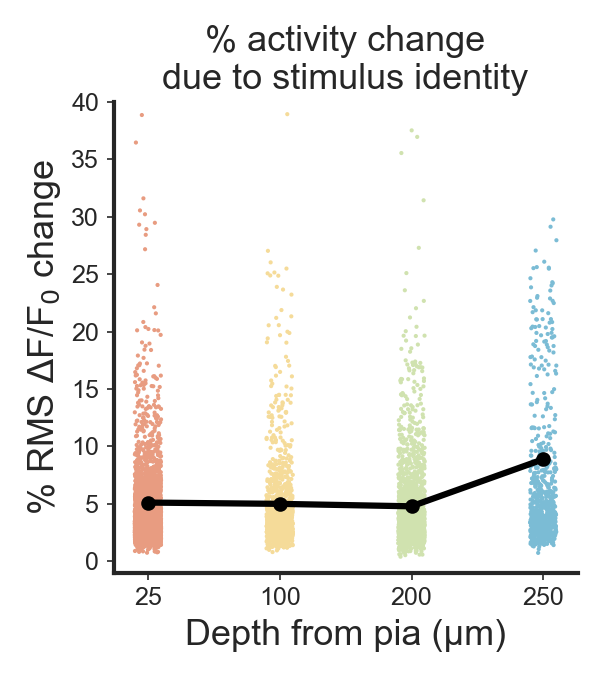

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_13848\1636498202.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = image_response_df,x = 'depth_um', y = image_response_df[metric]*100,palette=cp,size=2)


In [42]:
metric = 'image_rms_dff'

fig,ax=plt.subplots(figsize=(4,4.5))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','right','top','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()
    
sns.stripplot(data = image_response_df,x = 'depth_um', y = image_response_df[metric]*100,palette=cp,size=2)

means = []

for depth in image_response_df['depth_um'].unique():
    dft = image_response_df[image_response_df['depth_um']==depth]
    mean = np.nanmean(dft[metric]*100)
    means.append(mean)
ax.plot(means,color='k',zorder=11,lw=3,marker='o')
ax.set_ylim(-1,40)

ax.set_ylabel('% RMS \u0394F/F$_{0}$ change')
ax.set_xlabel('Depth from pia (\u03BCm)')

ax.set_title('% activity change\ndue to stimulus identity')

fig.tight_layout()
filen = 'Image_RMS'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi= 300)

In [36]:
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# Pairwise depth comparisons
# ------------------------------------------------------------
depth_order = [25, 100, 200, 250]

pairwise_rows = []

for d1, d2 in itertools.combinations(depth_order, 2):
    x = image_response_df.loc[image_response_df["depth_um"] == d1, metric].dropna().to_numpy()
    y = image_response_df.loc[image_response_df["depth_um"] == d2, metric].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_rows.append(
        {
            "depth_1": d1,
            "depth_2": d2,
            "n_1": len(x),
            "n_2": len(y),
            "median_1": np.median(x),
            "median_2": np.median(y),
            "mean_1": np.mean(x),
            "mean_2": np.mean(y),
            "mw_u": stat,
            "p_uncorrected": p,
        }
    )

pairwise_stats = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# Multiple-comparisons correction
# ------------------------------------------------------------
reject, p_fdr, _, _ = multipletests(
    pairwise_stats["p_uncorrected"].values,
    alpha=0.05,
    method="fdr_bh",
)

pairwise_stats["p_fdr_bh"] = p_fdr
pairwise_stats["significant_fdr_bh"] = reject

pairwise_stats = pairwise_stats.sort_values("p_fdr_bh").reset_index(drop=True)

pairwise_stats

,depth_1,depth_2,n_1,n_2,median_1,median_2,mean_1,mean_2,mw_u,p_uncorrected,p_fdr_bh,significant_fdr_bh
0,25,250,3465,668,0.034380,0.044205,0.050986,0.088726,884784.0,4.867484e-22,2.920490e-21,True
1,100,250,1128,668,0.034891,0.044205,0.049869,0.088726,297651.0,9.583860e-14,2.875158e-13,True
2,200,250,1731,668,0.036433,0.044205,0.047732,0.088726,472810.0,4.293360e-12,8.586720e-12,True
3,25,200,3465,1731,0.034380,0.036433,0.050986,0.047732,2844752.0,2.481343e-03,3.722015e-03,True
4,100,200,1128,1731,0.034891,0.036433,0.049869,0.047732,946390.0,1.658268e-01,1.989921e-01,False
5,25,100,3465,1128,0.034380,0.034891,0.050986,0.049869,1920281.0,3.797258e-01,3.797258e-01,False


### Plot effect of depth by session

In [43]:
session_df = image_response_df[(image_response_df['session_order']>3)&(image_response_df['session_order']<7)]

<IPython.core.display.Javascript object>


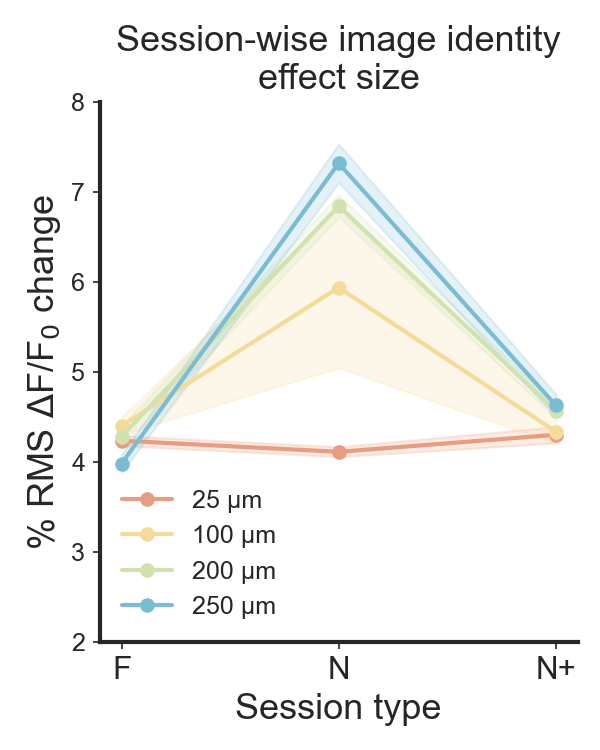

25
100
200
250


In [59]:
fig,ax = plt.subplots(figsize=(4,5))
sns.despine()
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

num_sessions = len(session_df['session_order'].unique())

for i,depth in enumerate(session_df['depth_um'].unique()):
    print(depth)
    dft = session_df[session_df['depth_um']==depth]
    mean = []
    sem = []
    for sess in sorted(dft['session_order'].unique()):
        sess_type = dft['session_type'][dft['session_order']==sess].unique()
        
        sess_mean = np.mean(dft[metric][dft['session_order']==sess])*100
        sess_sem = 50*np.std(dft[metric][dft['session_order']==sess])/np.sqrt(len(dft[dft['session_order']==sess]))
        
        mean.append(sess_mean)
        sem.append(sess_sem)
    ax.plot(mean,color=cp[i],lw=2,marker='o',label=f"{depth} \u03BCm")
    ax.fill_between(range(num_sessions),np.array(mean)+np.array(sem),np.array(mean)-np.array(sem),color=cp[i],alpha=0.2,zorder=0)
ax.set_xlabel('Session type')
ax.set_ylabel('% RMS \u0394F/F$_{0}$ change')

for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

ax.set_xticks(range(num_sessions))
ax.set_xticklabels(['F','N','N+'],fontsize=15)
ax.set_ylim(2,8)
    
ax.legend(frameon=False,fontsize=12)
ax.set_title('Session-wise image identity\neffect size')
fig.tight_layout()

filen = 'Session_RMS'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi= 300)

In [46]:
session_df['session_order'].unique()

array([4, 5, 6], dtype=int64)

### Plot a few trials from one synapse and image to get an idea of trial-to-trial noise

In [ ]:
exmaple_session = 33
example_asset = assets[exmaple_session]
example_traces = st_paths[exmaple_session]
example_dmd = 1
example_synapse = 56

In [ ]:
traces = np.load(example_traces,allow_pickle=True)['data'][0][f'DMD{example_dmd}']['image_identity']

In [ ]:
im_names = list(traces.keys())

In [ ]:
im_colors = [
    '#c5cae9', '#ffcdd2', '#c8e6c9', '#ffe0b2',
    '#e1bee7', '#d7ccc8',
    '#9fd3f2']

In [ ]:
# ------------------------------------------------------------
# Load single-trial traces
# Assumes shape per image = (n_trials, n_synapses, n_time)
# ------------------------------------------------------------

syn_idx = 56         # synapse 56 on DMD1
n_show = 10
trial_range = 150# ~5 sequential trials per image
sample_slice = slice(0,150)   # or e.g. slice(0, 150)

image_keys = list(traces.keys())
n_images = len(image_keys)

fig, axes = plt.subplots(
    n_images, 1,
    figsize=(8, 2.2 * n_images),
    sharex=True,
    sharey=True
)



fs = 200
flash_start = 50 / fs      # 0.25 s
flash_dur = 50 / fs        # 0.25 s
gray_dur = 100 / fs        # 0.5 s
cycle_dur = flash_dur + gray_dur

if n_images == 1:
    axes = [axes]

for i,(ax, im_key) in enumerate(zip(axes, image_keys)):
    
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    
    syn_trials = traces[im_key][trial_range:trial_range+n_show,syn_idx,:]  # (n_trials, n_synapses, n_time)
    im_label = Path(str(im_key)).stem

    trials_to_plot = np.concatenate(syn_trials)
    t = np.linspace(0,len(trials_to_plot)/fs,len(trials_to_plot))
    ax.plot(t,trials_to_plot,color='k',lw=1)
    
    for ii in range(n_show):
        start = flash_start + ii * cycle_dur
        end = start + flash_dur
        ax.axvspan(start, end, alpha=0.4, color=im_colors[i])
    
    # optional mean across shown trials
#     ax.plot(t, np.nanmean(syn_trials[:n_plot], axis=0), color="k", lw=2.5, alpha=0.9)

    ax.set_title(im_label, fontsize=11)
    ax.set_ylabel("Response")

axes[-1].set_xlabel("Time(s)")
fig.suptitle(f"Sequential image-presentation responses\nSynapse {syn_idx}, DMD{example_dmd}", y=0.99, fontsize=18)
fig.tight_layout()

In [ ]:
np.shape(traces[im_names[0]])

In [ ]:
traces[im_key][trial_range:trial_range+n_show,56,:] 